<a href="https://colab.research.google.com/github/AhmedB479/Pest-Prediction/blob/main/final_data_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import warnings
from sklearn.base import clone
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

# === Load and Prepare Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

# === Define Features & Targets ===
target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

random_states = [0]
all_model_results = []

# === REDUCED Parameter Grids (fewer combinations) ===
models = {
    "RandomForest": (RandomForestRegressor(), {
        'n_estimators': [100, 200],  # Reduced from [50, 100, 200]
        'max_depth': [10, None],     # Reduced from [5, 10, 15, None]
        'min_samples_split': [2, 5]
    }),
    "DecisionTree": (DecisionTreeRegressor(), {
        'max_depth': [5, 10, None],  # Reduced from [3, 5, 10, 15, None]
        'min_samples_split': [2, 5]  # Reduced from [2, 5, 10]
    }),
    "AdaBoost": (AdaBoostRegressor(), {
        'n_estimators': [100, 200],   # Reduced from [50, 100, 200]
        'learning_rate': [0.1, 1.0]  # Reduced from [0.01, 0.1, 0.5, 1.0]
    }),
    "SVM": (SVR(), {
        'C': [1, 10],                # Reduced from [0.1, 1, 10]
        'kernel': ['rbf'],           # Reduced from ['linear', 'rbf']
        'gamma': ['scale']           # Reduced from ['scale', 'auto']
    }),
    "KNN": (KNeighborsRegressor(), {
        'n_neighbors': [5, 7],       # Reduced from [3, 5, 7, 9]
        'weights': ['uniform', 'distance']
    }),
    "XGBoost": (XGBRegressor(), {
        'n_estimators': [100, 200],  # Reduced from [50, 100, 200]
        'max_depth': [3, 5],         # Reduced from [3, 5, 7]
        'learning_rate': [0.05, 0.1], # Reduced from [0.01, 0.05, 0.1]
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }),

    # === NEW ENSEMBLE METHODS ===
    "VotingRegressor": (VotingRegressor([
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
        ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
    ]), {}),  # No hyperparameter tuning for voting - using default good params

    "BaggingRegressor": (BaggingRegressor(
        estimator=DecisionTreeRegressor(), random_state=42)
    , {
        'n_estimators': [50, 100],   # Reduced search space
        'max_samples': [0.8, 1.0]
    }),

    "StackingRegressor": (StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
            ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
            ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
        ],
        final_estimator=LinearRegression(),
        cv=3
    ), {}),  # No hyperparameter tuning for stacking
}

def tune_model(X_train, y_train, base_model, params, n_iter=5, cv=3, random_state=None):
    """Parallelized hyperparameter tuning for a single target - REDUCED n_iter"""
    best_models = []

    def fit_single_target(i, target):
        model = clone(base_model)
        if hasattr(model, 'random_state'):
            model.random_state = random_state

        # Skip hyperparameter search if no parameters to tune
        if not params:
            model.fit(X_train, y_train.iloc[:, i])
            return model

        search = RandomizedSearchCV(
            model, params, n_iter=n_iter, cv=cv,
            scoring='r2', n_jobs=1, random_state=random_state
        )
        try:
            search.fit(X_train, y_train.iloc[:, i])
            return search.best_estimator_
        except:
            model.fit(X_train, y_train.iloc[:, i])
            return model

    # Parallel execution
    best_models = Parallel(n_jobs=-1)(
        delayed(fit_single_target)(i, target)
        for i, target in enumerate(y_train.columns)
    )

    return best_models

for model_name, (base_model, param_grid) in models.items():
    print(f"\n🚀 Processing: {model_name}")
    model_results = []

    for rnd in random_states:
        print(f"  🔁 Random State: {rnd}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=rnd
        )

        # Tune models in parallel (reduced from n_iter=10 to n_iter=5)
        estimators = tune_model(
            X_train, y_train, base_model, param_grid,
            n_iter=5, cv=3, random_state=rnd  # REDUCED from n_iter=10
        )

        # Create multi-output model
        model = MultiOutputRegressor(base_model)
        model.estimators_ = estimators

        # Predict and evaluate
        y_pred = model.predict(X_test)
        y_pred = np.clip(np.round(y_pred, 1), 0, None)

        metrics = []
        for i, col in enumerate(y_test.columns):
            r2 = r2_score(y_test[col], y_pred[:, i])
            mae = mean_absolute_error(y_test[col], y_pred[:, i])
            rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, i]))
            metrics.append([col, r2, mae, rmse])

        metrics_df = pd.DataFrame(metrics, columns=["Target", "R² Score", "MAE", "RMSE"])
        metrics_df["RandomState"] = rnd
        model_results.append(metrics_df)

    # Save and store results
    final_df = pd.concat(model_results, ignore_index=True)
    final_df["Model"] = model_name
    all_model_results.append(final_df)
    final_df.to_csv(f"{model_name}_results.csv", index=False)
    print(f"✅ Saved {model_name} results | Shape: {final_df.shape}")

# Combine all results
combined = pd.concat(all_model_results, ignore_index=True)
combined.to_csv("all_model_results.csv", index=False)

# === ENSEMBLE ANALYSIS ===
print("\n🔥 All models completed! Generating ensemble performance summary...")

# Calculate average performance by model
summary = combined.groupby('Model')[['R² Score', 'MAE', 'RMSE']].agg(['mean', 'std']).round(4)
summary.to_csv("model_performance_summary.csv")

print("\n📊 Model Performance Summary:")
print(summary.sort_values(('R² Score', 'mean'), ascending=False))

print("\n🏆 Best performing models by R² Score:")
best_models = combined.groupby('Model')['R² Score'].mean().sort_values(ascending=False)
print(best_models.head(3))

print("\n✨ Results saved to CSV files!")


🚀 Processing: RandomForest
  🔁 Random State: 0


KeyboardInterrupt: 

In [2]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import warnings
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

# === Load and Prepare Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

# === Define Features & Targets ===
target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

random_states = [0, 21, 42, 77, 101]
all_model_results = []

# === Simplified Models without Hyperparameter Tuning ===
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "SVM": SVR(),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "VotingRegressor": VotingRegressor([
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
        ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
    ]),
    "BaggingRegressor": BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=50,
        random_state=42
    ),
    "StackingRegressor": StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
            ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
            ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
        ],
        final_estimator=LinearRegression(),
        cv=3
    )
}

def train_predict_single_target(model, X_train, y_train, X_test):
    """Train and predict for a single target"""
    model.fit(X_train, y_train)
    return model.predict(X_test)

for model_name, base_model in models.items():
    print(f"\n🚀 Processing: {model_name}")
    model_results = []

    for rnd in random_states:
        print(f"  🔁 Random State: {rnd}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=rnd
        )

        # Train models in parallel
        predictions = Parallel(n_jobs=-1)(
            delayed(train_predict_single_target)(
                clone(base_model), X_train, y_train[col], X_test
            )
            for col in y_train.columns
        )

        # Convert predictions to numpy array
        y_pred = np.array(predictions).T
        y_pred = np.clip(np.round(y_pred, 1), 0, None)

        metrics = []
        for i, col in enumerate(y_test.columns):
            r2 = r2_score(y_test[col], y_pred[:, i])
            mae = mean_absolute_error(y_test[col], y_pred[:, i])
            rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, i]))
            metrics.append([col, r2, mae, rmse])

        metrics_df = pd.DataFrame(metrics, columns=["Target", "R² Score", "MAE", "RMSE"])
        metrics_df["RandomState"] = rnd
        model_results.append(metrics_df)

    # Save and store results
    final_df = pd.concat(model_results, ignore_index=True)
    final_df["Model"] = model_name
    all_model_results.append(final_df)
    final_df.to_csv(f"{model_name}_results.csv", index=False)
    print(f"✅ Saved {model_name} results | Shape: {final_df.shape}")

# Combine all results
combined = pd.concat(all_model_results, ignore_index=True)
combined.to_csv("all_model_results.csv", index=False)

# === Performance Analysis ===
print("\n🔥 All models completed! Generating performance summary...")

# Calculate average performance by model
summary = combined.groupby('Model')[['R² Score', 'MAE', 'RMSE']].agg(['mean', 'std']).round(4)
summary.to_csv("model_performance_summary.csv")

print("\n📊 Model Performance Summary:")
print(summary.sort_values(('R² Score', 'mean'), ascending=False))

print("\n🏆 Best performing models by R² Score:")
best_models = combined.groupby('Model')['R² Score'].mean().sort_values(ascending=False)
print(best_models.head(3))

print("\n✨ Results saved to CSV files!")


🚀 Processing: RandomForest
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved RandomForest results | Shape: (120, 6)

🚀 Processing: DecisionTree
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved DecisionTree results | Shape: (120, 6)

🚀 Processing: AdaBoost
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved AdaBoost results | Shape: (120, 6)

🚀 Processing: SVM
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved SVM results | Shape: (120, 6)

🚀 Processing: KNN
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved KNN results | Shape: (120, 6)

🚀 Processing: XGBoost
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved XGBoost 

In [21]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
import os
from joblib import dump


warnings.filterwarnings("ignore")

# === Load and Prepare Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

# === Define Features & Targets ===
target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Pick the best model
best_model_name = "StackingRegressor"
best_model = clone(models[best_model_name])

# Train separately for each target (multi-output training)
trained_models = {}
for target in y.columns:
    model = clone(best_model)
    model.fit(X_train, y_train[target])  # Train on training set only
    trained_models[target] = model

# Define the folder name
model_dir = "best_models_train_split"

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save models to the folder
for target, model in trained_models.items():
    filename = f"{model_dir}/best_model_{best_model_name}_{target}.joblib"
    dump(model, filename)

print(f"✅ All models saved to '{model_dir}/'")

print("✅ Models trained on training data.")

✅ All models saved to 'best_models_train_split/'
✅ Models trained on training data.



🔍 Interpreting model for target: W. FLY(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 98%|===================| 2872/2916 [00:16<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: JASSID(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 95%|=================== | 2765/2916 [00:15<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: THRIPS(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


...

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: WILT(%SPOT)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 2879/2916 [00:17<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: WILT(%AREA)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 94%|=================== | 2748/2916 [00:17<00:01]       

  ➤ Running LIME on sample 0...

✅ All interpretation calculations completed!

🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 7

🎨 Showing all visualizations...


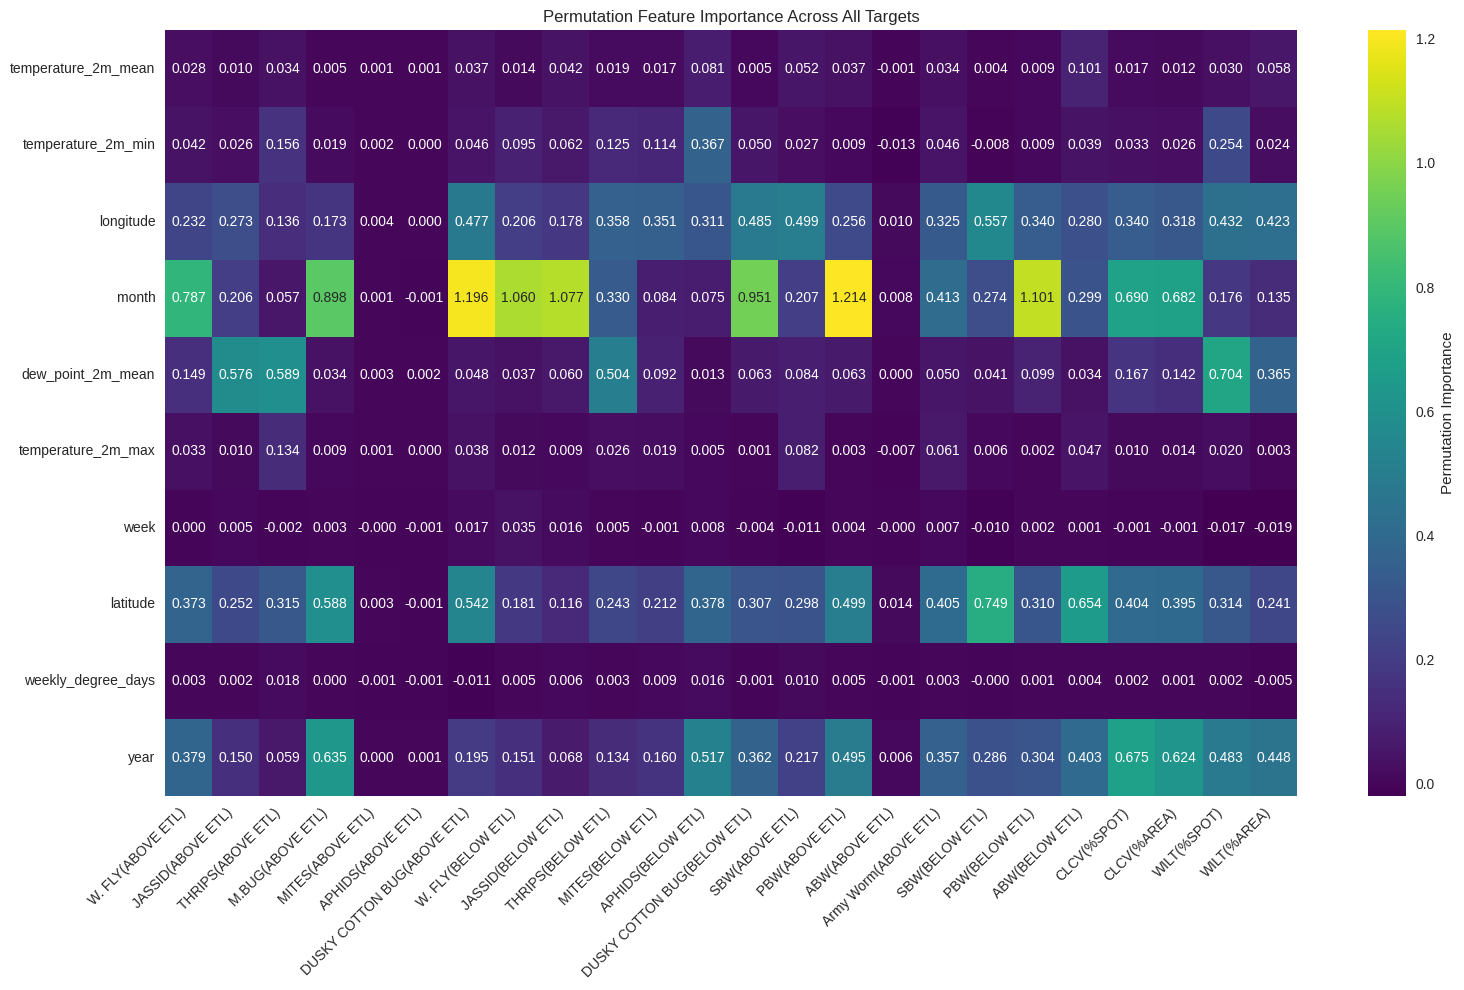

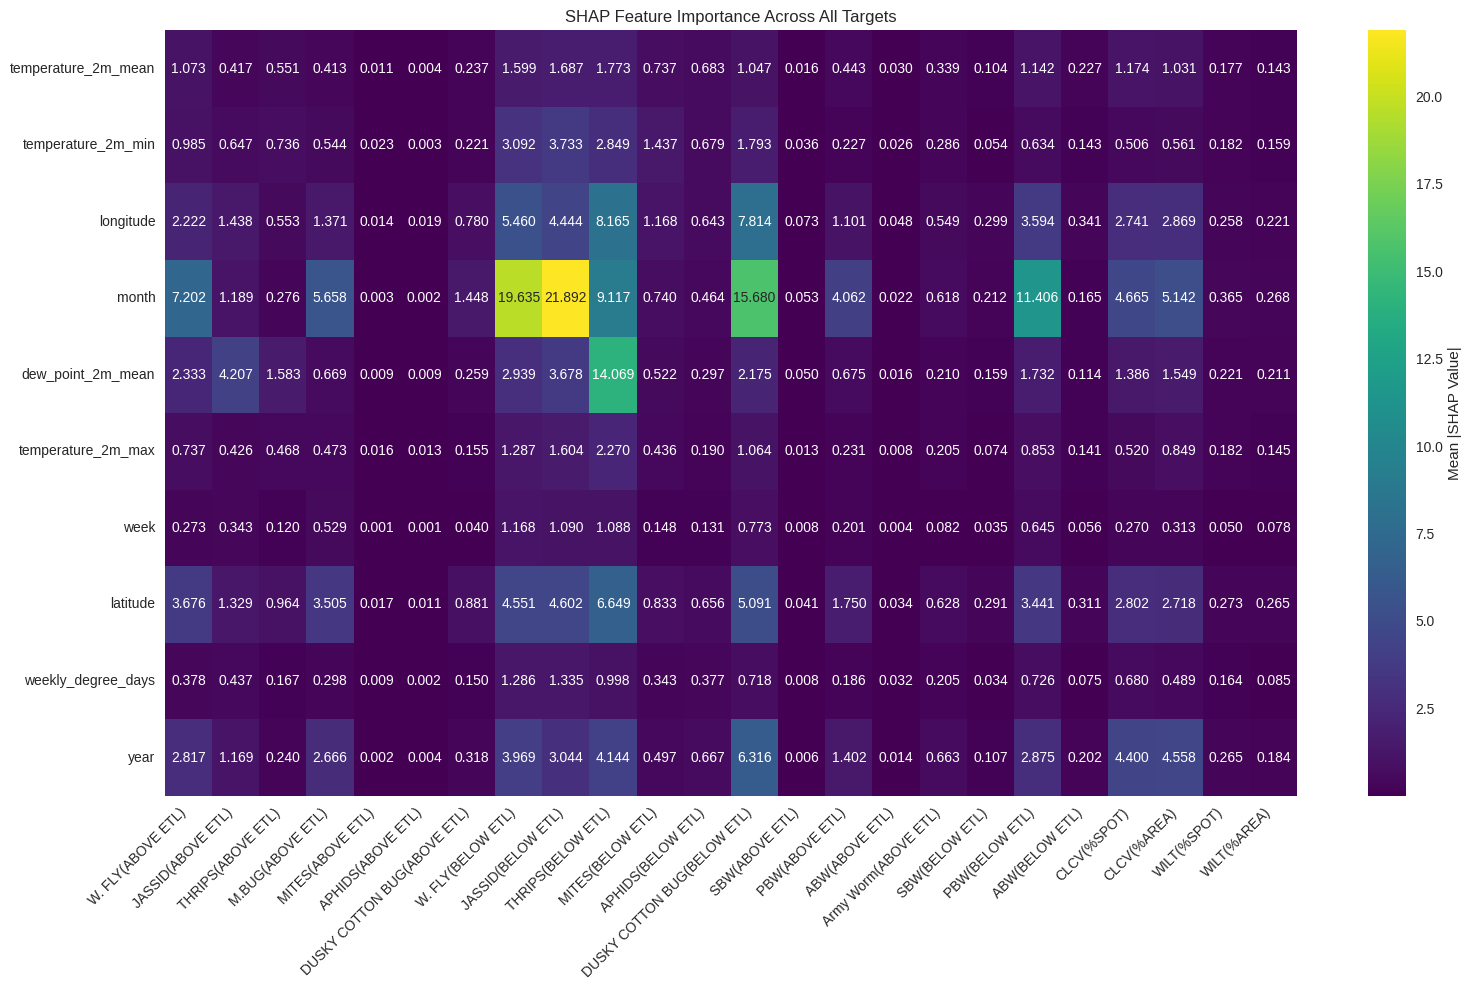

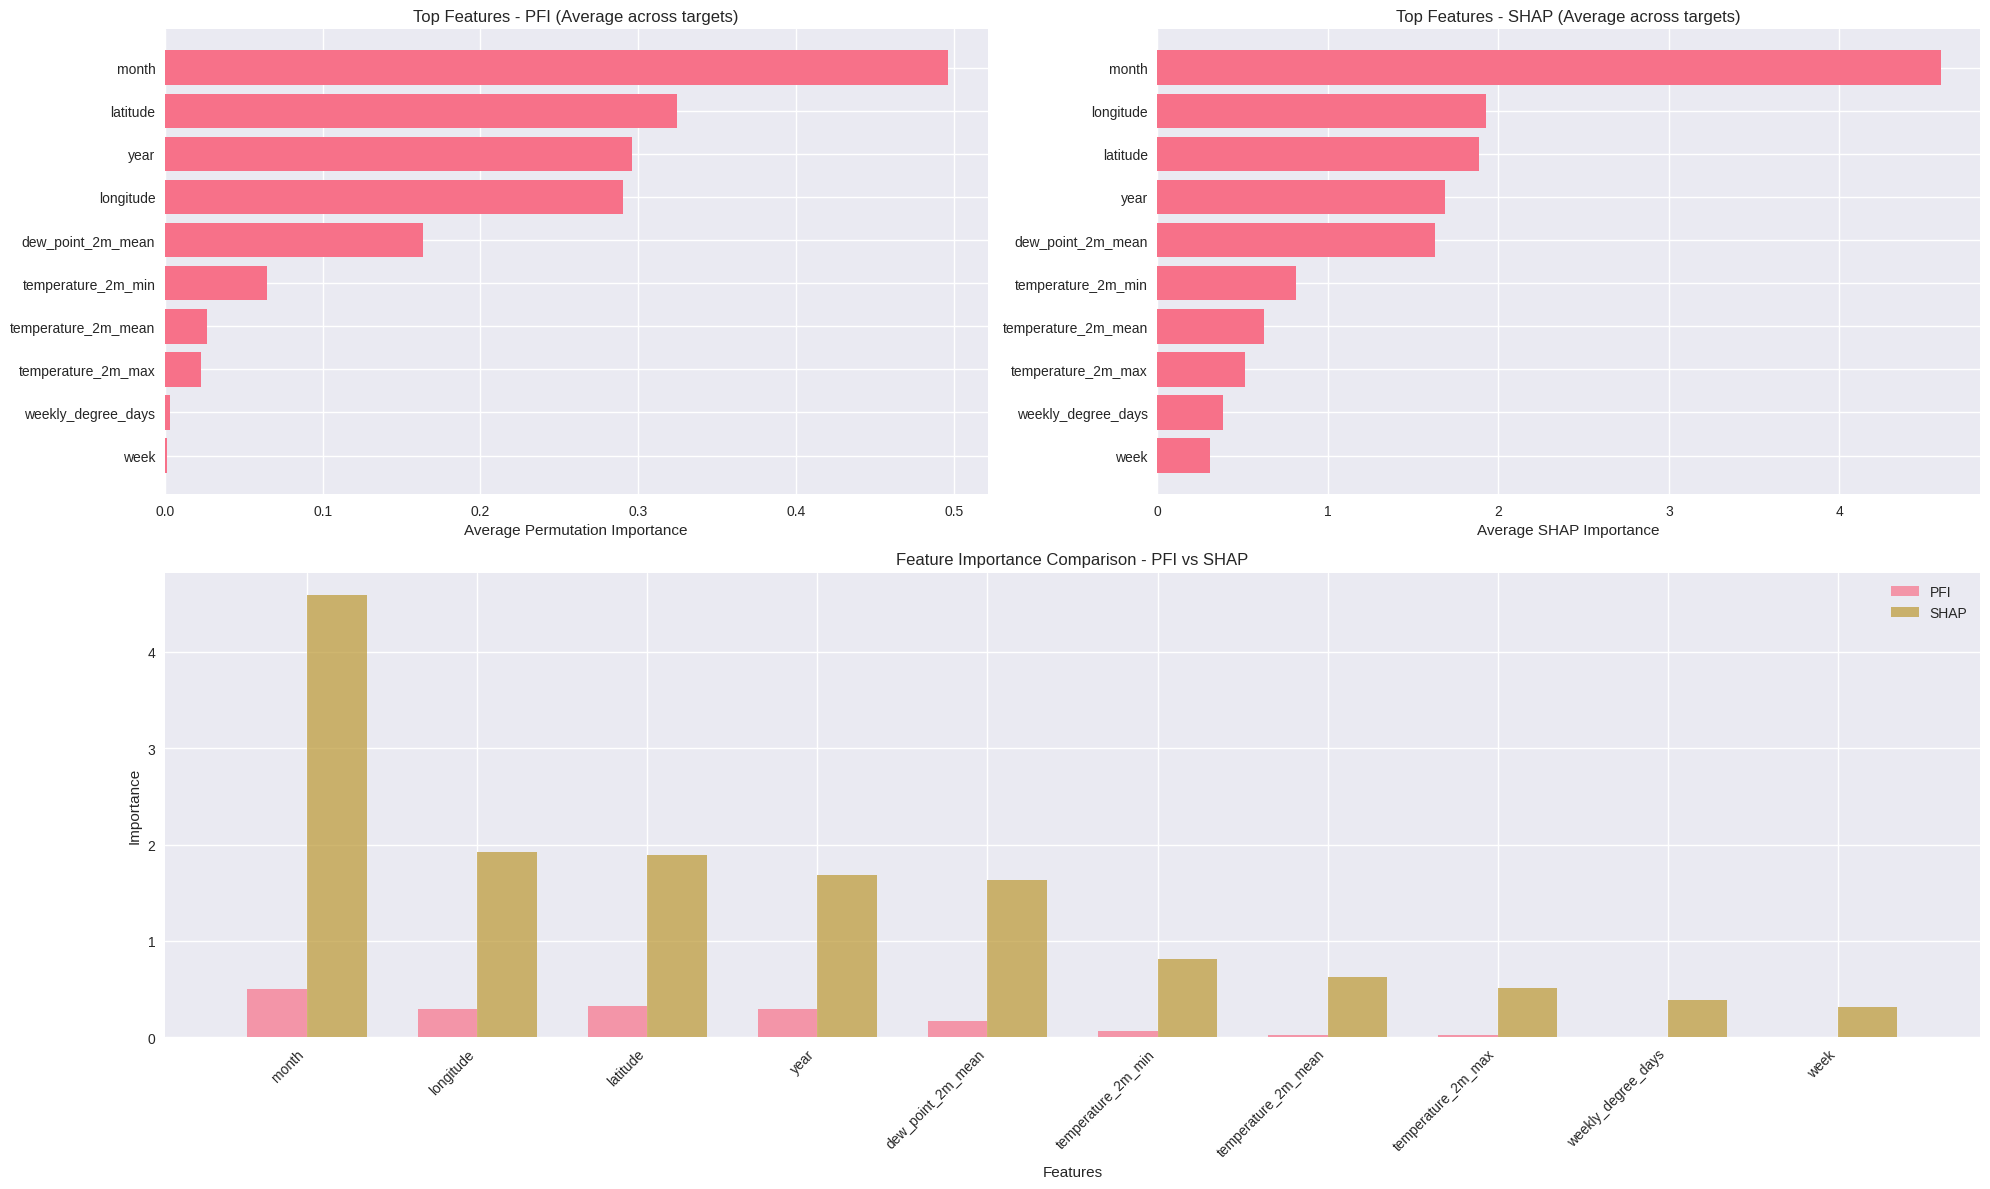


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 3

Available targets: ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)', 'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)', 'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)', 'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)', 'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)', 'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)', 'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)', 'WILT(%SPOT)', 'WILT(%AREA)']
Enter target name: W. FLY(ABOVE ETL)


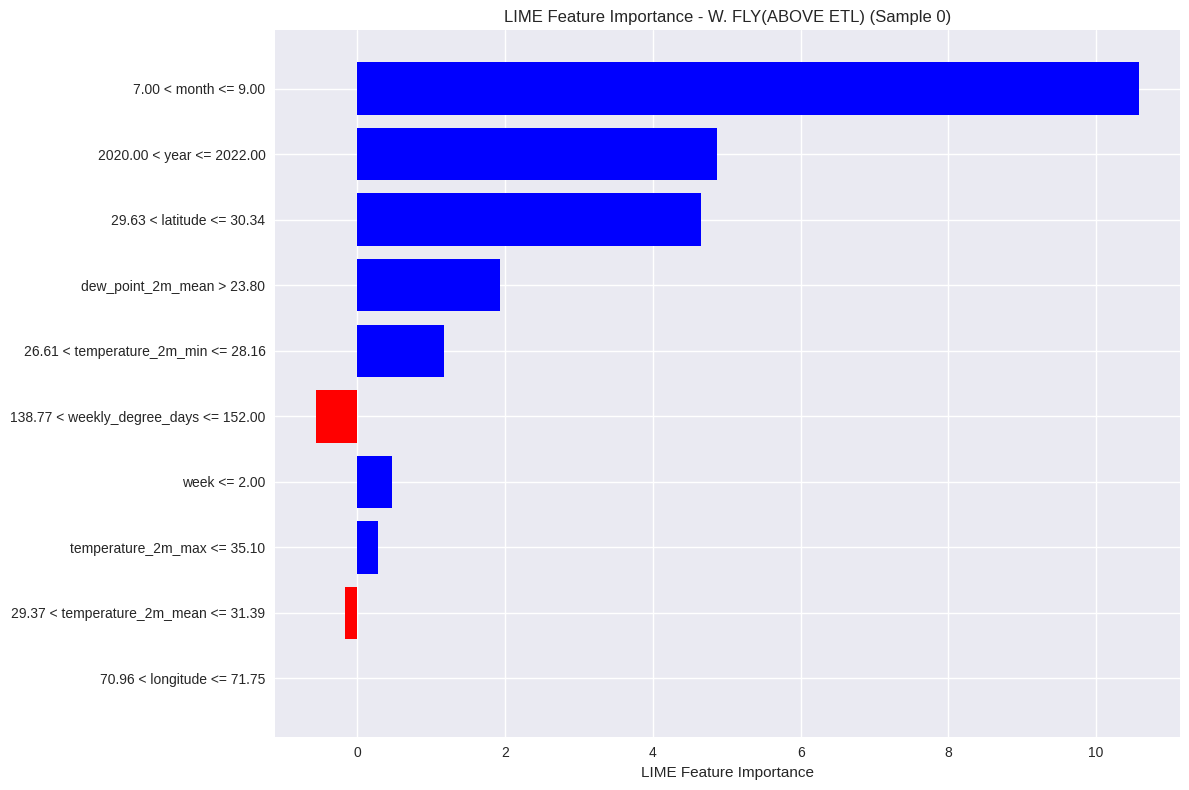


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 7

🎨 Showing all visualizations...


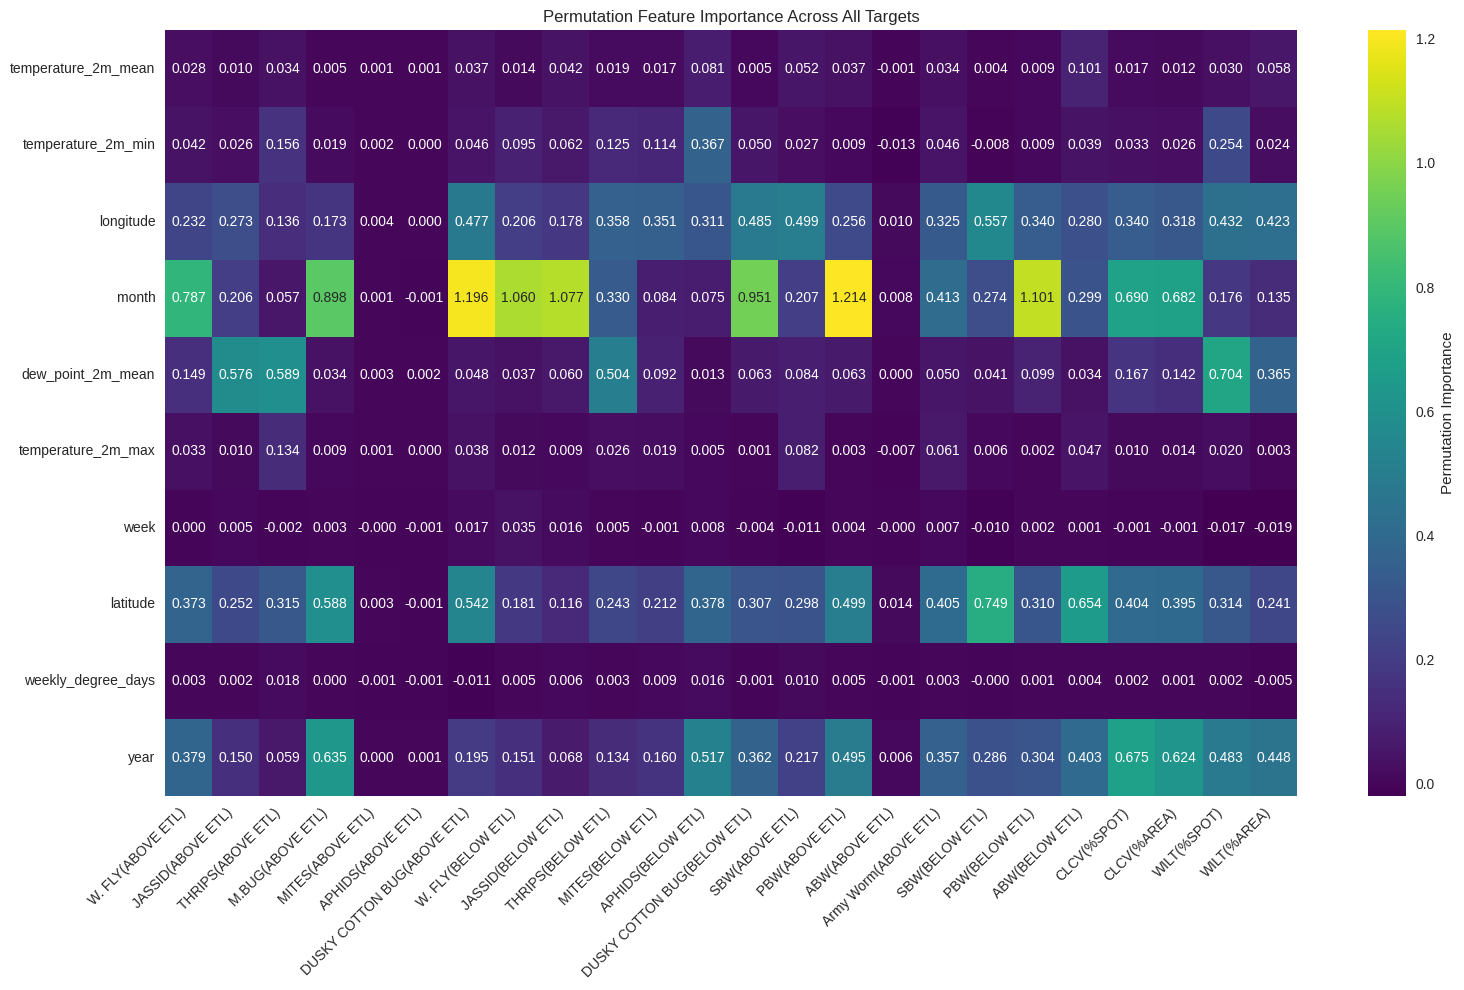

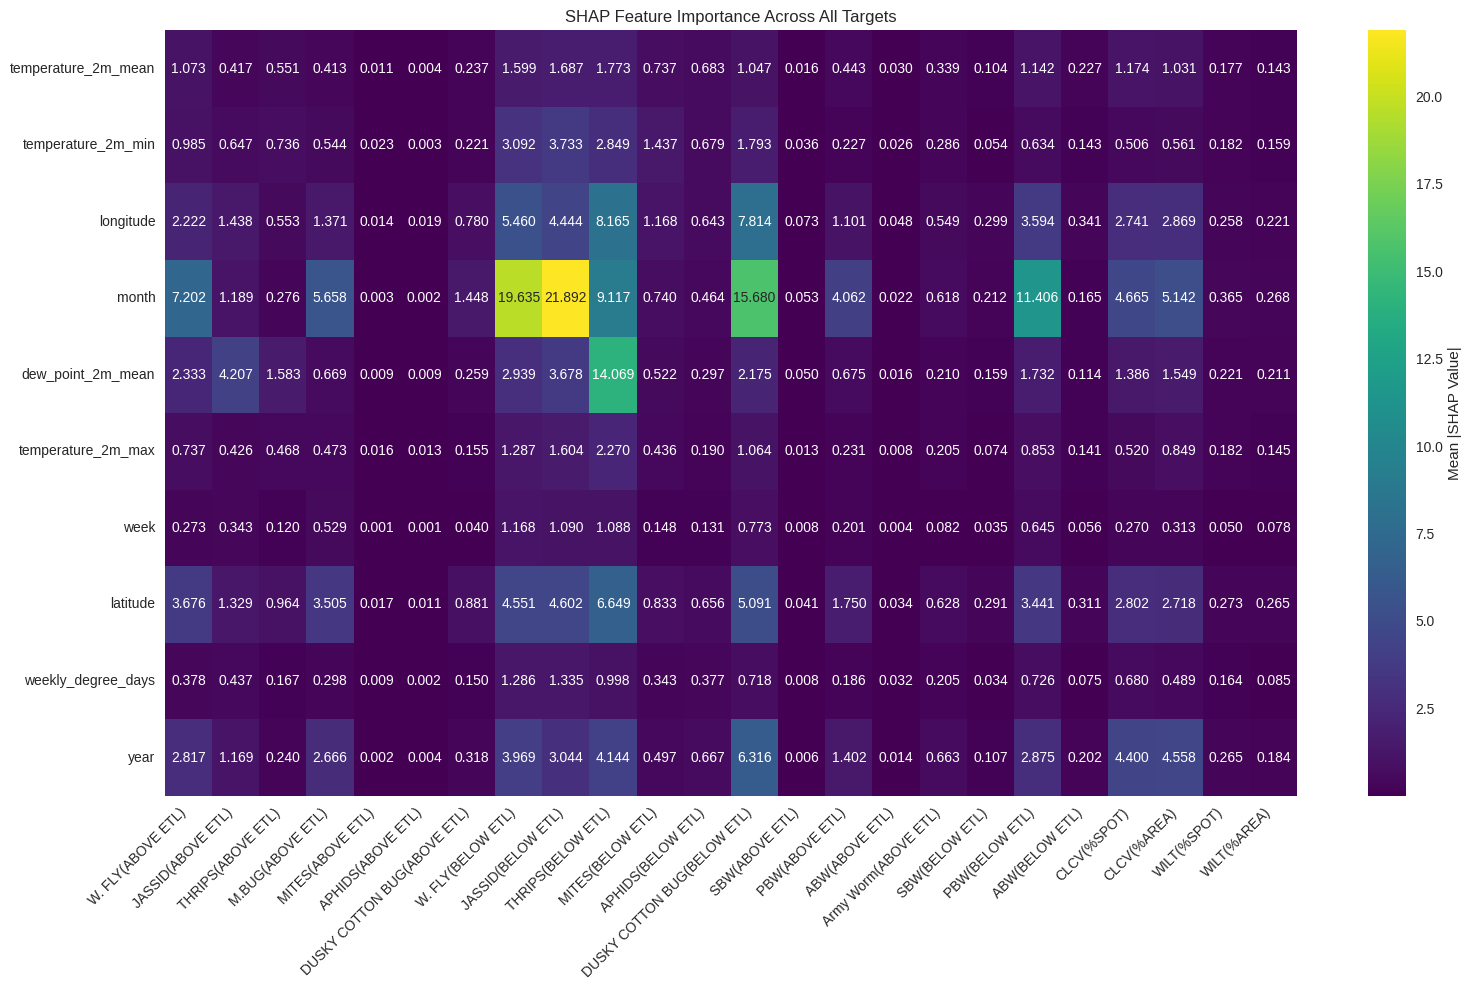

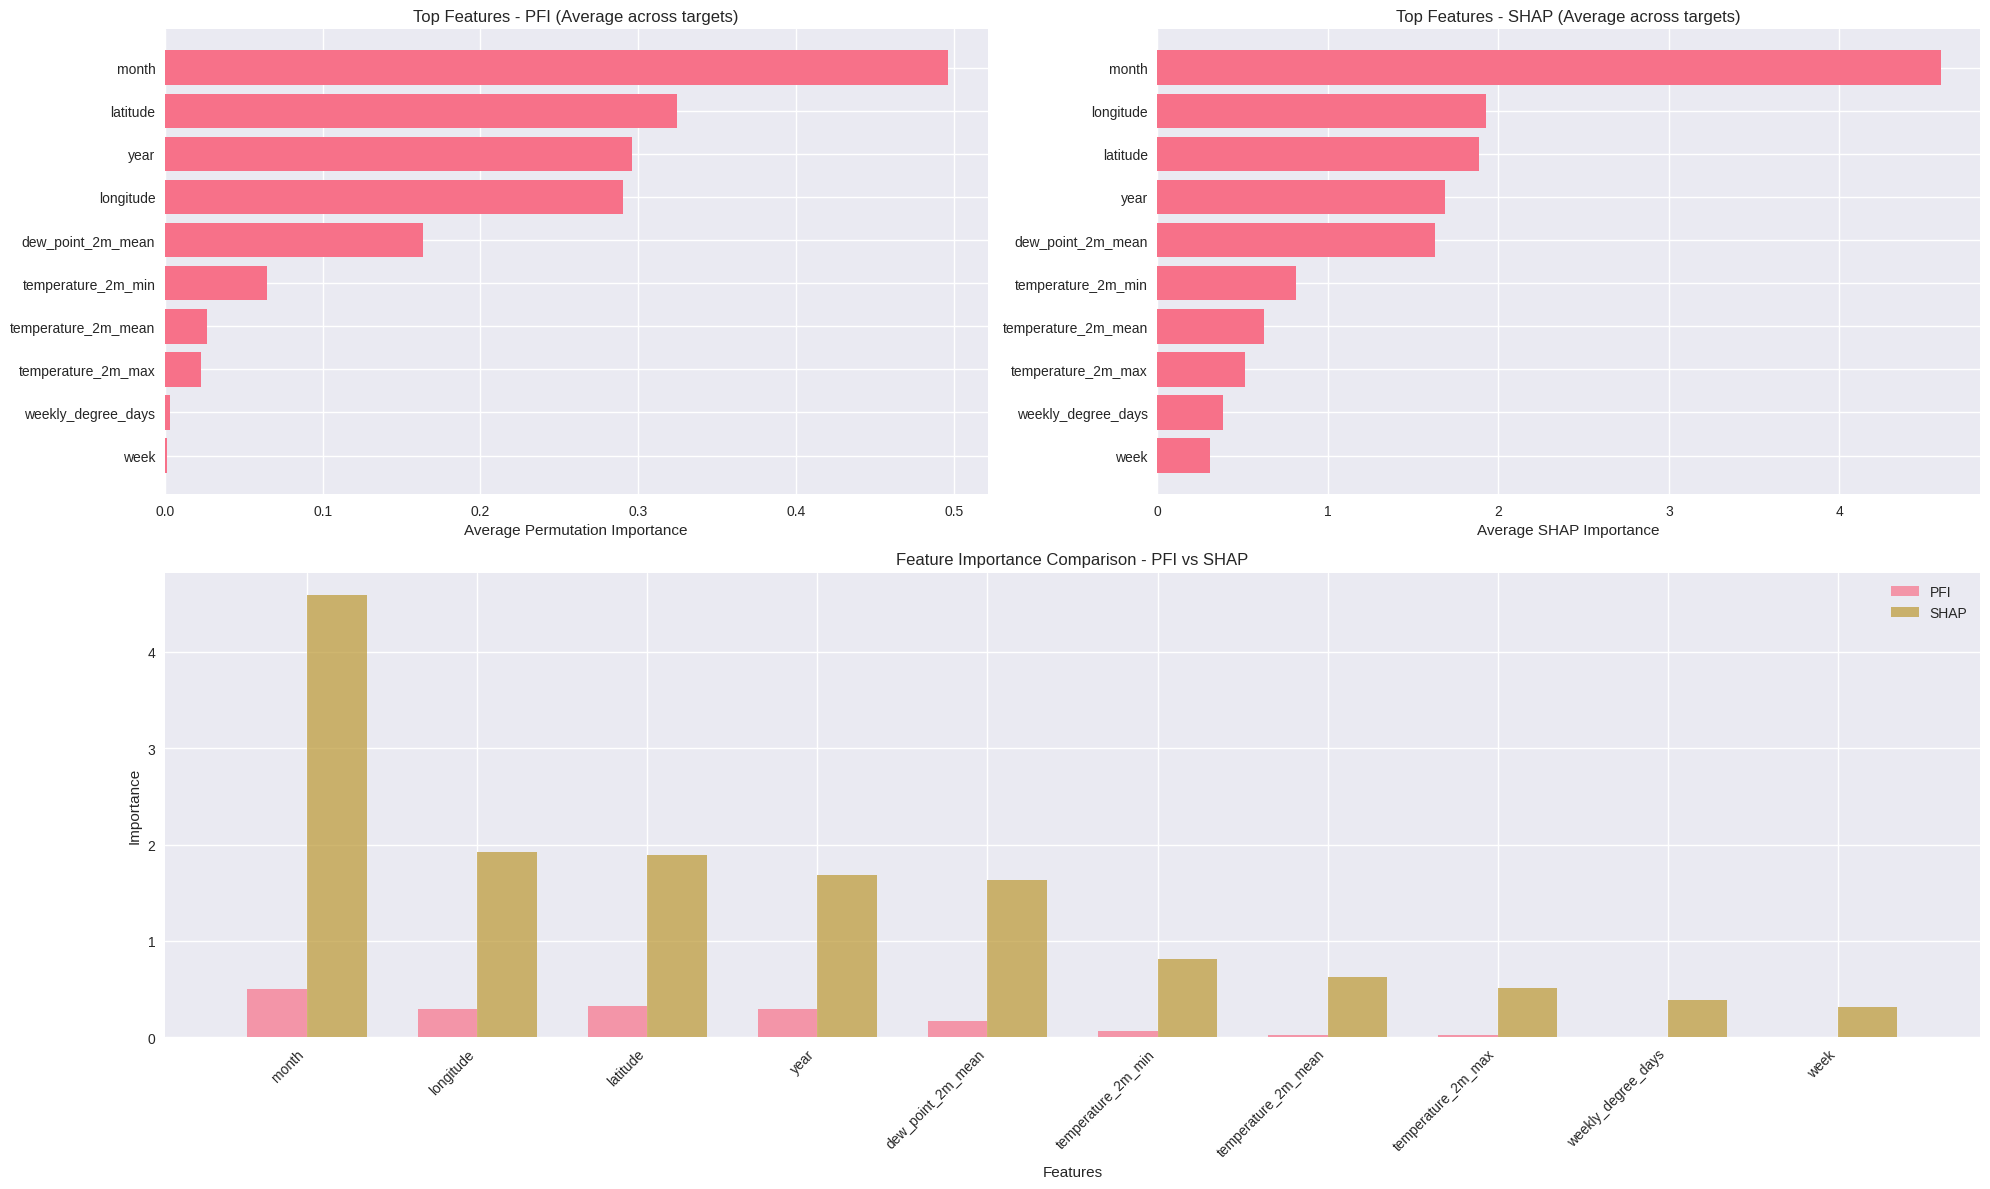


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit


KeyboardInterrupt: Interrupted by user

In [22]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set matplotlib style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



X = X_test
y = y_test

# === Define paths ===
model_dir = "best_models_train_split"
output_dir = "model_interpretation_train_test_outputs"
os.makedirs(output_dir, exist_ok=True)

# === LIME Explainer Setup (Global) ===
lime_explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    mode='regression',
    random_state=42
)

# === Storage for all results ===
all_pfi_results = {}
all_shap_results = {}
all_lime_results = {}

# === Loop through all target models ===
for target in target_cols:
    print(f"\n🔍 Interpreting model for target: {target}")
    model_path = os.path.join(model_dir, f"best_model_StackingRegressor_{target}.joblib")
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping missing model for: {target}")
        continue

    model = joblib.load(model_path)

    # === 1. Permutation Feature Importance (PFI) ===
    print(f"  ➤ Calculating PFI...")
    pfi_result = permutation_importance(model, X, y[target], n_repeats=10, random_state=42)
    sorted_idx = pfi_result.importances_mean.argsort()[::-1]

    # Store PFI results
    all_pfi_results[target] = {
        'importances': pfi_result.importances_mean,
        'features': X.columns,
        'sorted_idx': sorted_idx
    }

    # === 2. SHAP (using XGBoost only, as surrogate model) ===
    print(f"  ➤ Training XGBoost for SHAP...")
    xgb_model = XGBRegressor(n_estimators=100, random_state=42)
    xgb_model.fit(X, y[target])

    explainer = shap.Explainer(xgb_model, X)
    shap_values = explainer(X)

    # Store SHAP results
    all_shap_results[target] = {
        'shap_values': shap_values,
        'feature_importance': np.abs(shap_values.values).mean(0)
    }

    # === 3. LIME Explanation (on 1st sample) ===
    print(f"  ➤ Running LIME on sample 0...")
    sample_idx = 0
    instance = X.iloc[sample_idx].values

    lime_exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict
    )

    # Extract LIME feature importance
    lime_values = lime_exp.as_list()
    lime_features = [item[0] for item in lime_values]
    lime_importance = [item[1] for item in lime_values]

    all_lime_results[target] = {
        'features': lime_features,
        'importance': lime_importance
    }

print("\n✅ All interpretation calculations completed!")

# === VISUALIZATION FUNCTIONS ===

def plot_individual_pfi(target_name, max_features=15):
    """Plot PFI for a single target"""
    data = all_pfi_results[target_name]
    top_idx = data['sorted_idx'][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_idx)), data['importances'][top_idx])
    plt.yticks(range(len(top_idx)), data['features'][top_idx])
    plt.xlabel('Permutation Importance')
    plt.title(f'Permutation Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_shap(target_name, max_features=15):
    """Plot SHAP for a single target"""
    data = all_shap_results[target_name]
    sorted_idx = np.argsort(data['feature_importance'])[::-1][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(sorted_idx)), data['feature_importance'][sorted_idx])
    plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'SHAP Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_lime(target_name, max_features=15):
    """Plot LIME for a single target"""
    data = all_lime_results[target_name]
    # Sort by absolute importance
    sorted_pairs = sorted(zip(data['features'], data['importance']),
                         key=lambda x: abs(x[1]), reverse=True)[:max_features]

    features, importance = zip(*sorted_pairs)
    colors = ['red' if imp < 0 else 'blue' for imp in importance]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(features)), importance, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('LIME Feature Importance')
    plt.title(f'LIME Feature Importance - {target_name} (Sample 0)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_comparison_heatmap(method='pfi', max_features=10):
    """Create heatmap comparing feature importance across all targets"""
    if method == 'pfi':
        data_dict = all_pfi_results
        title = 'Permutation Feature Importance Across All Targets'
        ylabel = 'Permutation Importance'
    elif method == 'shap':
        data_dict = all_shap_results
        title = 'SHAP Feature Importance Across All Targets'
        ylabel = 'Mean |SHAP Value|'

    # Get top features across all targets
    all_features = set()
    for target_data in data_dict.values():
        if method == 'pfi':
            top_idx = target_data['sorted_idx'][:max_features]
            all_features.update(target_data['features'][top_idx])
        elif method == 'shap':
            sorted_idx = np.argsort(target_data['feature_importance'])[::-1][:max_features]
            all_features.update(X.columns[sorted_idx])

    # Create matrix
    feature_list = list(all_features)[:max_features]
    matrix = np.zeros((len(feature_list), len(data_dict)))

    for j, (target, target_data) in enumerate(data_dict.items()):
        for i, feature in enumerate(feature_list):
            if method == 'pfi':
                feature_idx = np.where(target_data['features'] == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['importances'][feature_idx[0]]
            elif method == 'shap':
                feature_idx = np.where(X.columns == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['feature_importance'][feature_idx[0]]

    plt.figure(figsize=(16, 10))
    sns.heatmap(matrix,
                xticklabels=list(data_dict.keys()),
                yticklabels=feature_list,
                annot=True,
                fmt='.3f',
                cmap='viridis',
                cbar_kws={'label': ylabel})
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_top_features_summary(max_features=10):
    """Plot top features across all methods for comparison"""
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(2, 2, figure=fig)

    # Get most important features from each method
    pfi_features = {}
    shap_features = {}

    for target in all_pfi_results.keys():
        pfi_data = all_pfi_results[target]
        top_idx = pfi_data['sorted_idx'][:max_features]
        for idx in top_idx:
            feature = pfi_data['features'][idx]
            if feature not in pfi_features:
                pfi_features[feature] = []
            pfi_features[feature].append(pfi_data['importances'][idx])

    for target in all_shap_results.keys():
        shap_data = all_shap_results[target]
        sorted_idx = np.argsort(shap_data['feature_importance'])[::-1][:max_features]
        for idx in sorted_idx:
            feature = X.columns[idx]
            if feature not in shap_features:
                shap_features[feature] = []
            shap_features[feature].append(shap_data['feature_importance'][idx])

    # Average importance across targets
    pfi_avg = {k: np.mean(v) for k, v in pfi_features.items()}
    shap_avg = {k: np.mean(v) for k, v in shap_features.items()}

    # Sort and plot
    pfi_sorted = sorted(pfi_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]
    shap_sorted = sorted(shap_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]

    # PFI plot
    ax1 = fig.add_subplot(gs[0, 0])
    features, importance = zip(*pfi_sorted)
    ax1.barh(range(len(features)), importance)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Average Permutation Importance')
    ax1.set_title('Top Features - PFI (Average across targets)')
    ax1.invert_yaxis()

    # SHAP plot
    ax2 = fig.add_subplot(gs[0, 1])
    features, importance = zip(*shap_sorted)
    ax2.barh(range(len(features)), importance)
    ax2.set_yticks(range(len(features)))
    ax2.set_yticklabels(features)
    ax2.set_xlabel('Average SHAP Importance')
    ax2.set_title('Top Features - SHAP (Average across targets)')
    ax2.invert_yaxis()

    # Combined comparison
    ax3 = fig.add_subplot(gs[1, :])
    all_features = set(pfi_avg.keys()) | set(shap_avg.keys())
    combined_data = []

    for feature in all_features:
        pfi_val = pfi_avg.get(feature, 0)
        shap_val = shap_avg.get(feature, 0)
        combined_data.append((feature, pfi_val, shap_val))

    combined_data = sorted(combined_data, key=lambda x: x[1] + x[2], reverse=True)[:max_features]

    features, pfi_vals, shap_vals = zip(*combined_data)
    x = np.arange(len(features))
    width = 0.35

    ax3.bar(x - width/2, pfi_vals, width, label='PFI', alpha=0.7)
    ax3.bar(x + width/2, shap_vals, width, label='SHAP', alpha=0.7)
    ax3.set_xlabel('Features')
    ax3.set_ylabel('Importance')
    ax3.set_title('Feature Importance Comparison - PFI vs SHAP')
    ax3.set_xticks(x)
    ax3.set_xticklabels(features, rotation=45, ha='right')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# === INTERACTIVE MENU ===
def display_menu():
    print("\n" + "="*60)
    print("🔍 MODEL INTERPRETATION VISUALIZATIONS")
    print("="*60)
    print("1. Individual PFI plots")
    print("2. Individual SHAP plots")
    print("3. Individual LIME plots")
    print("4. PFI Heatmap (all targets)")
    print("5. SHAP Heatmap (all targets)")
    print("6. Top Features Summary (PFI vs SHAP)")
    print("7. All visualizations")
    print("0. Exit")
    print("="*60)

def main_menu():
    while True:
        display_menu()
        choice = input("\nEnter your choice (0-7): ").strip()

        if choice == '0':
            print("👋 Goodbye!")
            break
        elif choice == '1':
            print(f"\nAvailable targets: {list(all_pfi_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_pfi_results:
                plot_individual_pfi(target)
            else:
                print("❌ Target not found!")
        elif choice == '2':
            print(f"\nAvailable targets: {list(all_shap_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_shap_results:
                plot_individual_shap(target)
            else:
                print("❌ Target not found!")
        elif choice == '3':
            print(f"\nAvailable targets: {list(all_lime_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_lime_results:
                plot_individual_lime(target)
            else:
                print("❌ Target not found!")
        elif choice == '4':
            plot_comparison_heatmap('pfi')
        elif choice == '5':
            plot_comparison_heatmap('shap')
        elif choice == '6':
            plot_top_features_summary()
        elif choice == '7':
            print("\n🎨 Showing all visualizations...")
            plot_comparison_heatmap('pfi')
            plot_comparison_heatmap('shap')
            plot_top_features_summary()
        else:
            print("❌ Invalid choice! Please try again.")

# === RUN INTERACTIVE MENU ===
if __name__ == "__main__":
    main_menu()

In [5]:
import os
from joblib import dump

# Define the folder name
model_dir = "best_models"

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save models to the folder
for target, model in trained_models.items():
    filename = f"{model_dir}/best_model_{best_model_name}_{target}.joblib"
    dump(model, filename)

print(f"✅ All models saved to '{model_dir}/'")


✅ All models saved to 'best_models/'


In [8]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3081809d6d2f2fb80b160d3ca0b7b1c56467d29d4e41f1ba44fd39cff649467a
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [13]:
import shutil
from google.colab import files

# Define source directory and output ZIP filename
model_dir = "best_models"
zip_filename = "best_models.zip"

# Create ZIP file
shutil.make_archive("best_models", 'zip', model_dir)

print(f"✅ '{zip_filename}' created successfully.")

files.download("best_models.zip")



✅ 'best_models.zip' created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = df.drop(columns=target_cols)
y = df[target_cols]

# Pick the best model
best_model_name = "StackingRegressor"
best_model = clone(models[best_model_name])

# Train separately for each target (multi-output training)
trained_models = {}
for target in y.columns:
    model = clone(best_model)
    model.fit(X, y[target])  # Train on training set only
    trained_models[target] = model

print("✅ Models trained on training data.")


🔍 Interpreting model for target: W. FLY(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 9587/9720 [00:52<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: JASSID(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 9624/9720 [00:51<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: THRIPS(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


...

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: WILT(%SPOT)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 9586/9720 [00:55<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: WILT(%AREA)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


100%|===================| 9686/9720 [00:57<00:00]       

  ➤ Running LIME on sample 0...

✅ All interpretation calculations completed!

🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 3

Available targets: ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)', 'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)', 'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)', 'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)', 'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)', 'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)', 'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)', 'WILT(%SPOT)', 'WILT(%AREA)']
Enter target name: W. FLY(ABOVE ETL)


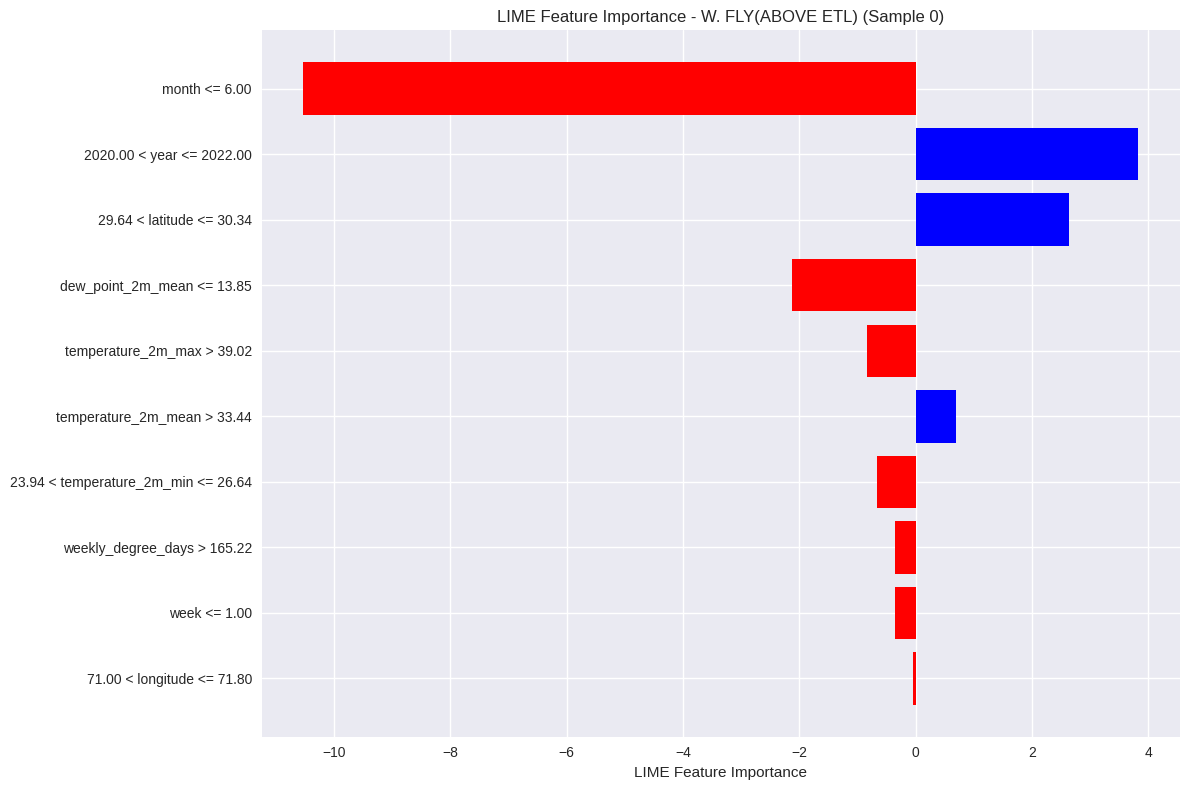


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 6


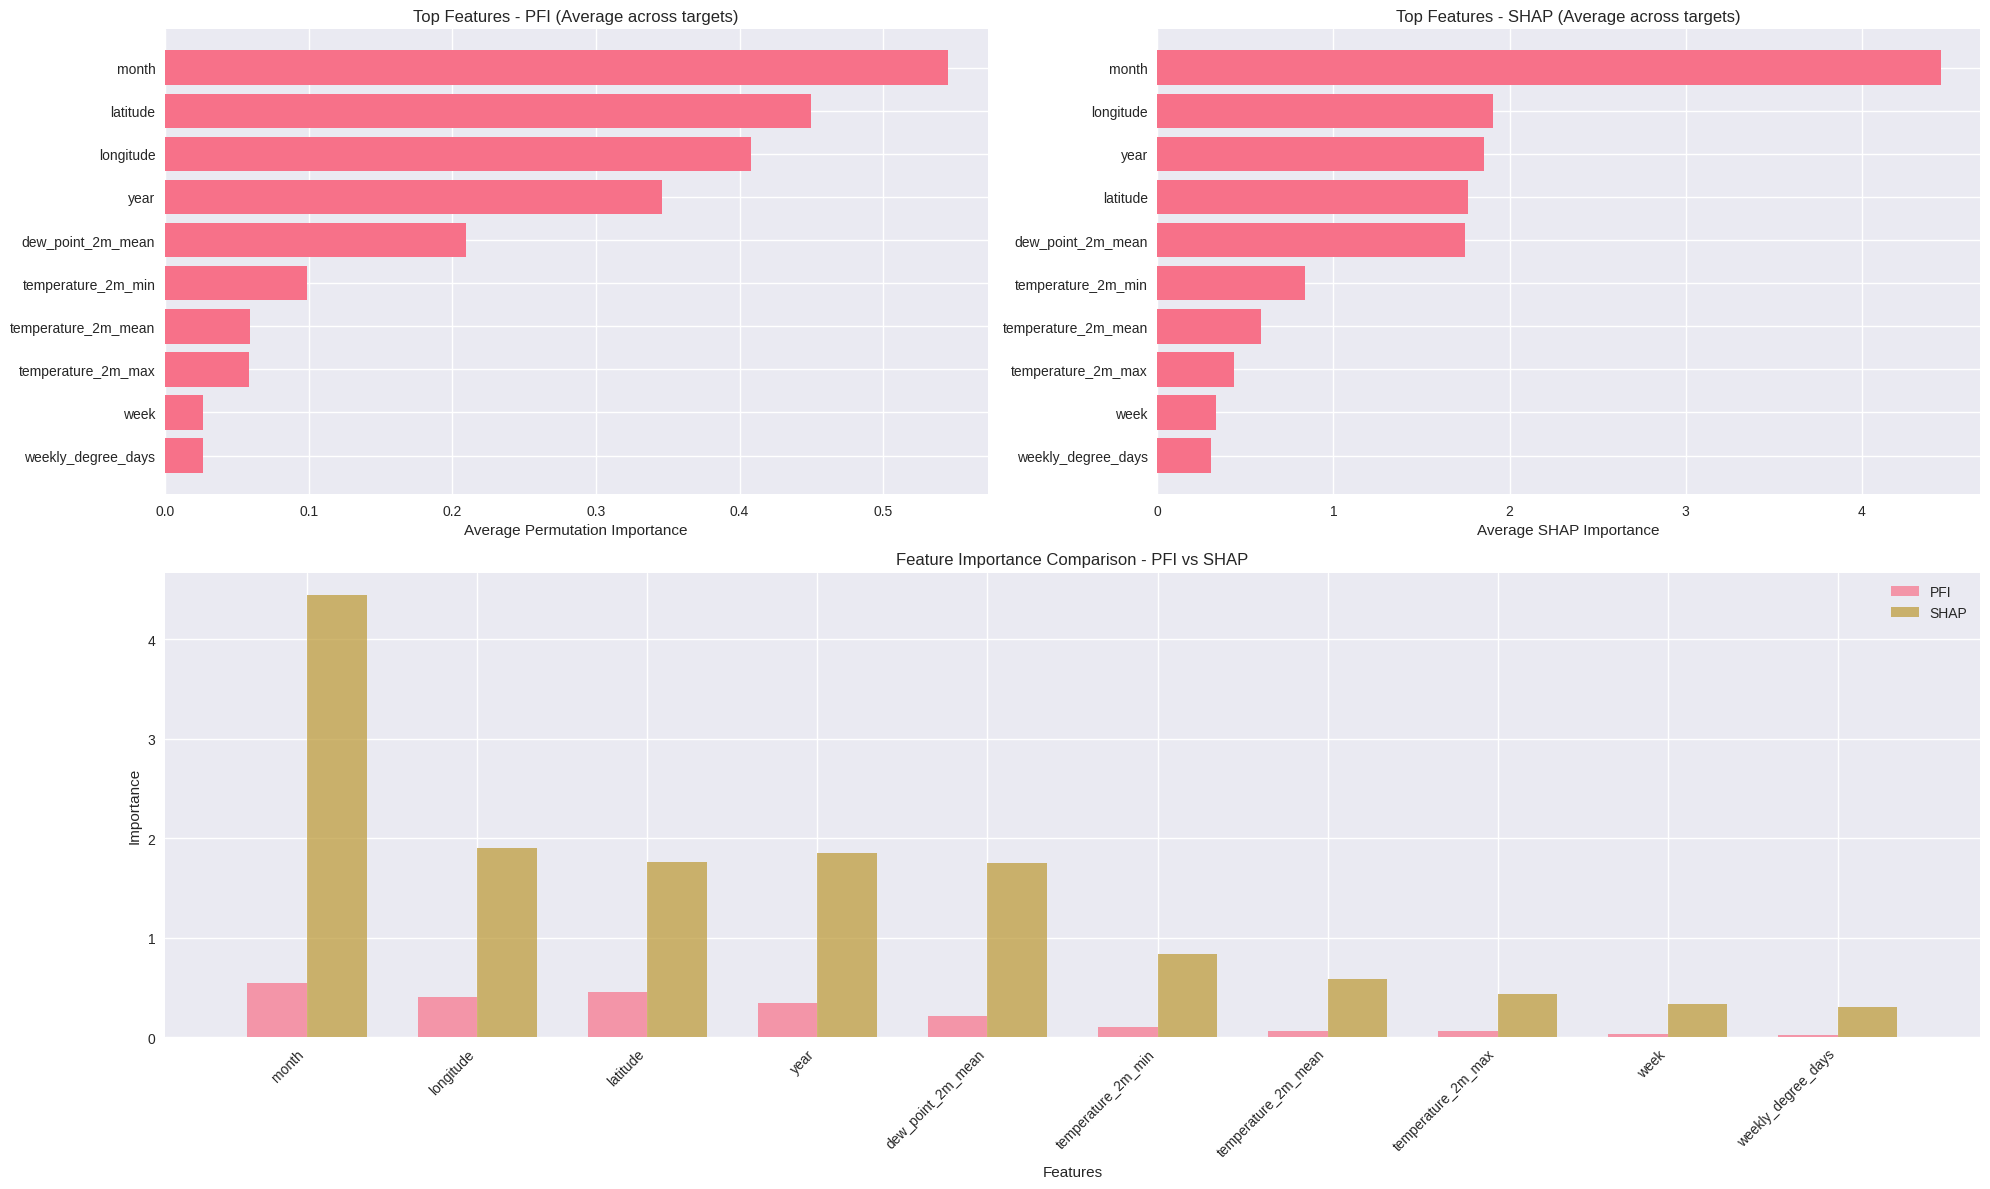


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit


KeyboardInterrupt: Interrupted by user

In [15]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set matplotlib style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# === Load Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

# === Define paths ===
model_dir = "best_models"
output_dir = "model_interpretation_outputs"
os.makedirs(output_dir, exist_ok=True)

# === LIME Explainer Setup (Global) ===
lime_explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    mode='regression',
    random_state=42
)

# === Storage for all results ===
all_pfi_results = {}
all_shap_results = {}
all_lime_results = {}

# === Loop through all target models ===
for target in target_cols:
    print(f"\n🔍 Interpreting model for target: {target}")
    model_path = os.path.join(model_dir, f"best_model_StackingRegressor_{target}.joblib")
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping missing model for: {target}")
        continue

    model = joblib.load(model_path)

    # === 1. Permutation Feature Importance (PFI) ===
    print(f"  ➤ Calculating PFI...")
    pfi_result = permutation_importance(model, X, y[target], n_repeats=10, random_state=42)
    sorted_idx = pfi_result.importances_mean.argsort()[::-1]

    # Store PFI results
    all_pfi_results[target] = {
        'importances': pfi_result.importances_mean,
        'features': X.columns,
        'sorted_idx': sorted_idx
    }

    # === 2. SHAP (using XGBoost only, as surrogate model) ===
    print(f"  ➤ Training XGBoost for SHAP...")
    xgb_model = XGBRegressor(n_estimators=100, random_state=42)
    xgb_model.fit(X, y[target])

    explainer = shap.Explainer(xgb_model, X)
    shap_values = explainer(X)

    # Store SHAP results
    all_shap_results[target] = {
        'shap_values': shap_values,
        'feature_importance': np.abs(shap_values.values).mean(0)
    }

    # === 3. LIME Explanation (on 1st sample) ===
    print(f"  ➤ Running LIME on sample 0...")
    sample_idx = 0
    instance = X.iloc[sample_idx].values

    lime_exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict
    )

    # Extract LIME feature importance
    lime_values = lime_exp.as_list()
    lime_features = [item[0] for item in lime_values]
    lime_importance = [item[1] for item in lime_values]

    all_lime_results[target] = {
        'features': lime_features,
        'importance': lime_importance
    }

print("\n✅ All interpretation calculations completed!")

# === VISUALIZATION FUNCTIONS ===

def plot_individual_pfi(target_name, max_features=15):
    """Plot PFI for a single target"""
    data = all_pfi_results[target_name]
    top_idx = data['sorted_idx'][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_idx)), data['importances'][top_idx])
    plt.yticks(range(len(top_idx)), data['features'][top_idx])
    plt.xlabel('Permutation Importance')
    plt.title(f'Permutation Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_shap(target_name, max_features=15):
    """Plot SHAP for a single target"""
    data = all_shap_results[target_name]
    sorted_idx = np.argsort(data['feature_importance'])[::-1][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(sorted_idx)), data['feature_importance'][sorted_idx])
    plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'SHAP Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_lime(target_name, max_features=15):
    """Plot LIME for a single target"""
    data = all_lime_results[target_name]
    # Sort by absolute importance
    sorted_pairs = sorted(zip(data['features'], data['importance']),
                         key=lambda x: abs(x[1]), reverse=True)[:max_features]

    features, importance = zip(*sorted_pairs)
    colors = ['red' if imp < 0 else 'blue' for imp in importance]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(features)), importance, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('LIME Feature Importance')
    plt.title(f'LIME Feature Importance - {target_name} (Sample 0)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_comparison_heatmap(method='pfi', max_features=10):
    """Create heatmap comparing feature importance across all targets"""
    if method == 'pfi':
        data_dict = all_pfi_results
        title = 'Permutation Feature Importance Across All Targets'
        ylabel = 'Permutation Importance'
    elif method == 'shap':
        data_dict = all_shap_results
        title = 'SHAP Feature Importance Across All Targets'
        ylabel = 'Mean |SHAP Value|'

    # Get top features across all targets
    all_features = set()
    for target_data in data_dict.values():
        if method == 'pfi':
            top_idx = target_data['sorted_idx'][:max_features]
            all_features.update(target_data['features'][top_idx])
        elif method == 'shap':
            sorted_idx = np.argsort(target_data['feature_importance'])[::-1][:max_features]
            all_features.update(X.columns[sorted_idx])

    # Create matrix
    feature_list = list(all_features)[:max_features]
    matrix = np.zeros((len(feature_list), len(data_dict)))

    for j, (target, target_data) in enumerate(data_dict.items()):
        for i, feature in enumerate(feature_list):
            if method == 'pfi':
                feature_idx = np.where(target_data['features'] == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['importances'][feature_idx[0]]
            elif method == 'shap':
                feature_idx = np.where(X.columns == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['feature_importance'][feature_idx[0]]

    plt.figure(figsize=(16, 10))
    sns.heatmap(matrix,
                xticklabels=list(data_dict.keys()),
                yticklabels=feature_list,
                annot=True,
                fmt='.3f',
                cmap='viridis',
                cbar_kws={'label': ylabel})
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_top_features_summary(max_features=10):
    """Plot top features across all methods for comparison"""
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(2, 2, figure=fig)

    # Get most important features from each method
    pfi_features = {}
    shap_features = {}

    for target in all_pfi_results.keys():
        pfi_data = all_pfi_results[target]
        top_idx = pfi_data['sorted_idx'][:max_features]
        for idx in top_idx:
            feature = pfi_data['features'][idx]
            if feature not in pfi_features:
                pfi_features[feature] = []
            pfi_features[feature].append(pfi_data['importances'][idx])

    for target in all_shap_results.keys():
        shap_data = all_shap_results[target]
        sorted_idx = np.argsort(shap_data['feature_importance'])[::-1][:max_features]
        for idx in sorted_idx:
            feature = X.columns[idx]
            if feature not in shap_features:
                shap_features[feature] = []
            shap_features[feature].append(shap_data['feature_importance'][idx])

    # Average importance across targets
    pfi_avg = {k: np.mean(v) for k, v in pfi_features.items()}
    shap_avg = {k: np.mean(v) for k, v in shap_features.items()}

    # Sort and plot
    pfi_sorted = sorted(pfi_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]
    shap_sorted = sorted(shap_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]

    # PFI plot
    ax1 = fig.add_subplot(gs[0, 0])
    features, importance = zip(*pfi_sorted)
    ax1.barh(range(len(features)), importance)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Average Permutation Importance')
    ax1.set_title('Top Features - PFI (Average across targets)')
    ax1.invert_yaxis()

    # SHAP plot
    ax2 = fig.add_subplot(gs[0, 1])
    features, importance = zip(*shap_sorted)
    ax2.barh(range(len(features)), importance)
    ax2.set_yticks(range(len(features)))
    ax2.set_yticklabels(features)
    ax2.set_xlabel('Average SHAP Importance')
    ax2.set_title('Top Features - SHAP (Average across targets)')
    ax2.invert_yaxis()

    # Combined comparison
    ax3 = fig.add_subplot(gs[1, :])
    all_features = set(pfi_avg.keys()) | set(shap_avg.keys())
    combined_data = []

    for feature in all_features:
        pfi_val = pfi_avg.get(feature, 0)
        shap_val = shap_avg.get(feature, 0)
        combined_data.append((feature, pfi_val, shap_val))

    combined_data = sorted(combined_data, key=lambda x: x[1] + x[2], reverse=True)[:max_features]

    features, pfi_vals, shap_vals = zip(*combined_data)
    x = np.arange(len(features))
    width = 0.35

    ax3.bar(x - width/2, pfi_vals, width, label='PFI', alpha=0.7)
    ax3.bar(x + width/2, shap_vals, width, label='SHAP', alpha=0.7)
    ax3.set_xlabel('Features')
    ax3.set_ylabel('Importance')
    ax3.set_title('Feature Importance Comparison - PFI vs SHAP')
    ax3.set_xticks(x)
    ax3.set_xticklabels(features, rotation=45, ha='right')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# === INTERACTIVE MENU ===
def display_menu():
    print("\n" + "="*60)
    print("🔍 MODEL INTERPRETATION VISUALIZATIONS")
    print("="*60)
    print("1. Individual PFI plots")
    print("2. Individual SHAP plots")
    print("3. Individual LIME plots")
    print("4. PFI Heatmap (all targets)")
    print("5. SHAP Heatmap (all targets)")
    print("6. Top Features Summary (PFI vs SHAP)")
    print("7. All visualizations")
    print("0. Exit")
    print("="*60)

def main_menu():
    while True:
        display_menu()
        choice = input("\nEnter your choice (0-7): ").strip()

        if choice == '0':
            print("👋 Goodbye!")
            break
        elif choice == '1':
            print(f"\nAvailable targets: {list(all_pfi_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_pfi_results:
                plot_individual_pfi(target)
            else:
                print("❌ Target not found!")
        elif choice == '2':
            print(f"\nAvailable targets: {list(all_shap_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_shap_results:
                plot_individual_shap(target)
            else:
                print("❌ Target not found!")
        elif choice == '3':
            print(f"\nAvailable targets: {list(all_lime_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_lime_results:
                plot_individual_lime(target)
            else:
                print("❌ Target not found!")
        elif choice == '4':
            plot_comparison_heatmap('pfi')
        elif choice == '5':
            plot_comparison_heatmap('shap')
        elif choice == '6':
            plot_top_features_summary()
        elif choice == '7':
            print("\n🎨 Showing all visualizations...")
            plot_comparison_heatmap('pfi')
            plot_comparison_heatmap('shap')
            plot_top_features_summary()
        else:
            print("❌ Invalid choice! Please try again.")

# === RUN INTERACTIVE MENU ===
if __name__ == "__main__":
    main_menu()